In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

In [3]:
df = pd.read_csv("C:\DL\diabetes.csv", index_col=0)
df

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,,,,,,,,
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.340,27,0
5,121,72,23,112,26.2,0.245,30,0


In [4]:
new_df = df.drop('Outcome',axis=1)
new_df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,,,,,,,
6,148,72,35,0,33.6,0.627,50
1,85,66,29,0,26.6,0.351,31
8,183,64,0,0,23.3,0.672,32
1,89,66,23,94,28.1,0.167,21
0,137,40,35,168,43.1,2.288,33


In [5]:
X=new_df.drop('BMI',axis=1)
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
Pregnancies,,,,,,
6,148,72,35,0,0.627,50
1,85,66,29,0,0.351,31
8,183,64,0,0,0.672,32
1,89,66,23,94,0.167,21
0,137,40,35,168,2.288,33


In [6]:
y = df['BMI']
y.head()

Pregnancies
6    33.6
1    26.6
8    23.3
1    28.1
0    43.1
Name: BMI, dtype: float64

In [7]:
Y = pd.get_dummies(y).values

In [8]:
X = X.values

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0) 

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, 

((614, 6), (614, 248), (154, 6), (154, 248))

In [12]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

model.add(Dense(8,input_shape=(6,)))
model.add(Dense(30))
model.add(Dense(30))
model.add(Dense(1))

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 56        
                                                                 
 dense_1 (Dense)             (None, 30)                270       
                                                                 
 dense_2 (Dense)             (None, 30)                930       
                                                                 
 dense_3 (Dense)             (None, 1)                 31        
                                                                 
Total params: 1,287
Trainable params: 1,287
Non-trainable params: 0
_________________________________________________________________


In [25]:
N_EPOCHS = 10

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/10
20/20 [==============================] - 0s 10ms/step - loss: 0.5058 - mse: 0.5058 - val_loss: 0.1810 - val_mse: 0.1810
Epoch 2/10
20/20 [==============================] - 0s 5ms/step - loss: 0.4970 - mse: 0.4970 - val_loss: 0.9462 - val_mse: 0.9462
Epoch 3/10
20/20 [==============================] - 0s 7ms/step - loss: 0.4238 - mse: 0.4238 - val_loss: 0.0046 - val_mse: 0.0046
Epoch 4/10
20/20 [==============================] - 0s 7ms/step - loss: 0.8343 - mse: 0.8343 - val_loss: 5.2398 - val_mse: 5.2398
Epoch 5/10
20/20 [==============================] - 0s 7ms/step - loss: 0.4447 - mse: 0.4447 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 6/10
20/20 [==============================] - 0s 9ms/step - loss: 0.6621 - mse: 0.6621 - val_loss: 0.2369 - val_mse: 0.2369
Epoch 7/10
20/20 [==============================] - 0s 11ms/step - loss: 0.2170 - mse: 0.2170 - val_loss: 0.0714 - val_mse: 0.0714
Epoch 8/10
20/20 [==============================] - 0s 6ms/step - loss: 0.5954 - mse: 0.

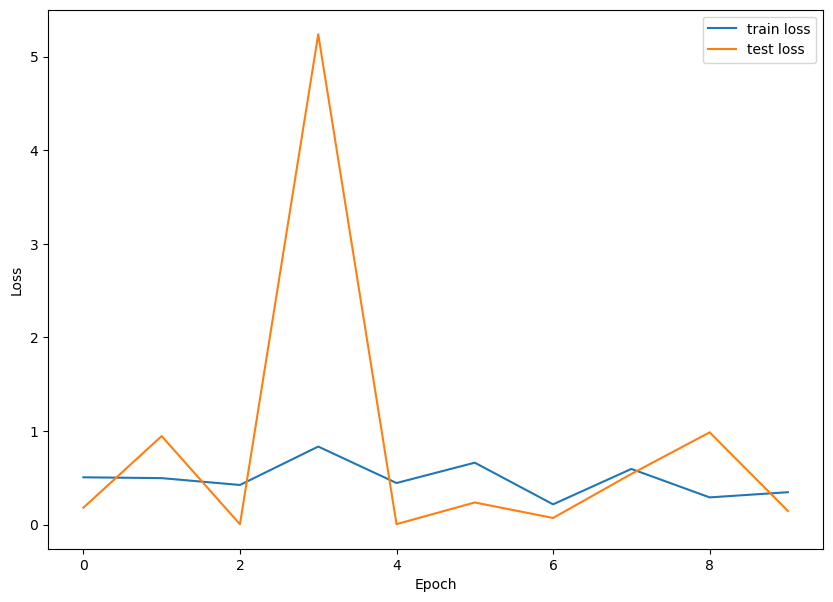

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [27]:
model.evaluate(X_test, y_test)

5/5 [==============================] - 0s 2ms/step - loss: 0.1465 - mse: 0.1465


[0.14646102488040924, 0.14646102488040924]